# M³TrustEval-XQuAD  
## Modular Multilingual Trustworthiness Evaluation of a HuggingFace LLM

### Course Project: Large Language Models

---

## 1. Project Summary

In this project, you will evaluate a single HuggingFace instruction-tuned language model on a real multilingual question-answering dataset.

The project focuses on five advanced LLM topics:

1. **Evaluation**
2. **Interpretability**
3. **Bias / Ethics**
4. **Modularity**
5. **Multilinguality**

The key idea is that LLM evaluation should not be limited to exact answer accuracy.  
A trustworthy evaluation should also ask:

- Does the model answer correctly?
- Is the explanation grounded in the given context?
- Does a modular verifier improve the answer?
- Does the model perform equally well across languages?
- Are there language-based performance disparities that raise fairness and ethical concerns?

---

## 2. Dataset and Model

### Dataset

We use **XQuAD** from HuggingFace:

- Dataset: `google/xquad`
- Task: Cross-lingual extractive question answering
- Languages used in this notebook: English, Arabic, German, Spanish, Turkish

XQuAD is useful here because the same QA examples are translated across multiple languages.  
This allows us to compare the same model across languages in a controlled way.

### Model

We use exactly one HuggingFace model:

- Model: `Qwen/Qwen2.5-0.5B-Instruct`

This is intentionally a small model so that the notebook can run on limited GPU resources.


# 3. Reference Papers and Links

This project is inspired by the following papers and resources.

## Main Evaluation Reference

**HELM: Holistic Evaluation of Language Models**  
Link: https://arxiv.org/abs/2211.09110

HELM motivates the idea that language models should be evaluated across multiple metrics, not just accuracy.

## Trustworthiness Reference

**DecodingTrust: A Comprehensive Assessment of Trustworthiness in GPT Models**  
Link: https://arxiv.org/abs/2306.11698

DecodingTrust motivates the trustworthiness perspective, including fairness, robustness, ethics, privacy, and bias.

## Modularity / Self-Consistency Reference

**SelfCheckGPT: Zero-Resource Black-Box Hallucination Detection for Generative LLMs**  
Link: https://arxiv.org/abs/2303.08896

SelfCheckGPT motivates checking model outputs through consistency and verification.

## Dataset Reference

**XQuAD: Cross-lingual Question Answering Dataset**  
HuggingFace: https://huggingface.co/datasets/google/xquad  
GitHub: https://github.com/google-deepmind/xquad

## Model Reference

**Qwen2.5-0.5B-Instruct**  
HuggingFace: https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct


# 4. Formal Project Statement

## Goal

Build a multilingual and modular evaluation framework for a HuggingFace LLM using the XQuAD dataset.

## Required Tasks

Students must:

1. Load the XQuAD dataset from HuggingFace.
2. Select a small multilingual subset from multiple languages.
3. Load one HuggingFace instruction-tuned model.
4. Run a **direct answering baseline**.
5. Run a **modular pipeline** consisting of:
   - generator
   - verifier
   - reviser
6. Compute answer quality metrics:
   - Exact Match
   - Token-level F1
7. Compute interpretability / faithfulness metrics:
   - whether the evidence appears in the context
   - whether the explanation is grounded in the context
8. Compute multilingual fairness metrics:
   - per-language performance
   - English vs. non-English gap
   - worst-language performance
   - language performance disparity
9. Compare the direct and modular systems.
10. Write a short discussion about bias, ethics, limitations, and possible improvements.

## Final Deliverables

Students should submit:

- completed notebook,
- generated CSV files,
- plots,
- final written analysis.

## Important Rule

Use only one LLM for generation and verification:

`Qwen/Qwen2.5-0.5B-Instruct`


# 5. Expected Research Questions

Your final report should answer:

1. Does the modular pipeline improve performance over the direct baseline?
2. Does the verifier improve explanation faithfulness?
3. Which language has the lowest performance?
4. Is there a large performance gap between English and non-English languages?
5. Can cross-lingual performance disparity be considered a form of language bias?
6. What are the ethical implications of deploying a model that performs much better in some languages than others?
7. What are the limitations of using the same model as both generator and verifier?
8. How could this project be extended to become a stronger research study?


# 6. Install Required Libraries

Run this cell in Colab, Kaggle, or a fresh local environment.

Recommended runtime:

- GPU enabled
- Internet enabled


In [36]:
!pip -q install datasets transformers accelerate torch pandas numpy matplotlib tqdm rapidfuzz tabulate


# 7. Imports and Configuration

This notebook intentionally uses only one HuggingFace LLM.

You may reduce `N_EXAMPLES_PER_LANGUAGE` for quick debugging.  
For the final run, use a larger number if your GPU allows it.


In [37]:
import os
import re
import json
import random
import warnings
from typing import Dict, List, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from rapidfuzz import fuzz

import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
DATASET_ID = "google/xquad"

# XQuAD configurations used in this project.
LANG_CONFIGS = {
    "en": "xquad.en",
    "ar": "xquad.ar",
    "de": "xquad.de",
    "es": "xquad.es",
    "tr": "xquad.tr",
}

# Use 2 or 3 for quick debugging; increase for a stronger final experiment.
N_EXAMPLES_PER_LANGUAGE = 3

MAX_CONTEXT_CHARS = 1600
MAX_NEW_TOKENS = 220

pd.set_option("display.max_colwidth", 220)

print("CUDA available:", torch.cuda.is_available())
print("Model:", MODEL_ID)
print("Dataset:", DATASET_ID)


CUDA available: True
Model: Qwen/Qwen2.5-0.5B-Instruct
Dataset: google/xquad


# 8. Load the XQuAD Dataset

We load the same dataset in several languages.  
Then we keep examples that have matching IDs across languages, so that the same underlying QA item can be compared cross-lingually.


In [39]:
def first_answer(answers):
    """
    Extract the first answer string from the XQuAD answers field.
    """
    if isinstance(answers, dict):
        texts = answers.get("text", [])
        if isinstance(texts, list) and len(texts) > 0:
            return texts[0]
        return ""
    return ""


def load_xquad_multilingual_subset(
    dataset_id: str,
    lang_configs: Dict[str, str],
    n_examples_per_language: int,
) -> pd.DataFrame:
    lang_dfs = {}
    
    for lang, config in lang_configs.items():
        ds = load_dataset(dataset_id, config, split="validation")
        df = ds.to_pandas()
        
        # Important fix:
        # Some versions of google/xquad do not include a "title" column.
        # We create a fallback title so the rest of the notebook remains stable.
        if "title" not in df.columns:
            df["title"] = config
        
        df["lang"] = lang
        df["gold_answer"] = df["answers"].apply(first_answer)
        lang_dfs[lang] = df
        
    common_ids = None
    for lang, df in lang_dfs.items():
        ids = set(df["id"].astype(str).tolist())
        common_ids = ids if common_ids is None else common_ids.intersection(ids)
    
    common_ids = sorted(list(common_ids))
    selected_ids = common_ids[:n_examples_per_language]
    
    rows = []
    for lang, df in lang_dfs.items():
        subset = df[df["id"].astype(str).isin(selected_ids)].copy()
        subset = subset.sort_values("id")
        rows.append(subset)
    
    final_df = pd.concat(rows, ignore_index=True)
    
    # Robust column selection.
    required_cols = ["id", "lang", "title", "context", "question", "gold_answer"]
    for col in required_cols:
        if col not in final_df.columns:
            final_df[col] = ""
    
    final_df = final_df[required_cols]
    return final_df


xquad_df = load_xquad_multilingual_subset(
    DATASET_ID,
    LANG_CONFIGS,
    N_EXAMPLES_PER_LANGUAGE
)

print("Number of examples:", len(xquad_df))
print("Columns:", list(xquad_df.columns))
display(xquad_df.head(10))

Number of examples: 15
Columns: ['id', 'lang', 'title', 'context', 'question', 'gold_answer']


,id,lang,title,context,question,gold_answer
0,56beb4343aeaaa14008c925b,en,xquad.en,"The Panthers defense gave up just 308 points, ranking sixth in the league, while also leading the NFL in interceptions with 24 and boasting four Pro Bowl selections. Pro Bowl defensive tackle Kawann Short led the tea...",How many points did the Panthers defense surrender?,
1,56beb4343aeaaa14008c925c,en,xquad.en,"The Panthers defense gave up just 308 points, ranking sixth in the league, while also leading the NFL in interceptions with 24 and boasting four Pro Bowl selections. Pro Bowl defensive tackle Kawann Short led the tea...",How many career sacks did Jared Allen have?,
2,56beb4343aeaaa14008c925d,en,xquad.en,"The Panthers defense gave up just 308 points, ranking sixth in the league, while also leading the NFL in interceptions with 24 and boasting four Pro Bowl selections. Pro Bowl defensive tackle Kawann Short led the tea...",How many tackles did Luke Kuechly register?,
3,56beb4343aeaaa14008c925b,ar,xquad.ar,لم يتخلى فريق بانثرز سوى عن 308 نقطة، ليحتل المركز السادس في الدوري، متصدراً في الوقت عينه دوري كرة القدم الأميركية في الاعتراضات مع 24 اعتراضاً ومتمتعاً بـ أربعة اختيارات في قائمة برو بول. وقد تصدر المدافع المعترض ك...,كم نقطة تخلى عنها دفاع البانثرز؟,
4,56beb4343aeaaa14008c925c,ar,xquad.ar,لم يتخلى فريق بانثرز سوى عن 308 نقطة، ليحتل المركز السادس في الدوري، متصدراً في الوقت عينه دوري كرة القدم الأميركية في الاعتراضات مع 24 اعتراضاً ومتمتعاً بـ أربعة اختيارات في قائمة برو بول. وقد تصدر المدافع المعترض ك...,كم عدد الاستحواذات التي قام بها جاريد ألين في مسيرته؟,
5,56beb4343aeaaa14008c925d,ar,xquad.ar,لم يتخلى فريق بانثرز سوى عن 308 نقطة، ليحتل المركز السادس في الدوري، متصدراً في الوقت عينه دوري كرة القدم الأميركية في الاعتراضات مع 24 اعتراضاً ومتمتعاً بـ أربعة اختيارات في قائمة برو بول. وقد تصدر المدافع المعترض ك...,كم عرقلة سجل لوك كوتشلي؟,
6,56beb4343aeaaa14008c925b,de,xquad.de,"Die Verteidigung der Panthers gab nur 308 Punkte ab und belegte den sechsten Platz in der Liga, während sie die NFL mit 24 Interceptions in dieser Kategorie anführte und sich mit vier Pro Bowl-Selektionen rühmen konn...",Wie viele Punkte gab die Verteidigung der Panthers ab?,
7,56beb4343aeaaa14008c925c,de,xquad.de,"Die Verteidigung der Panthers gab nur 308 Punkte ab und belegte den sechsten Platz in der Liga, während sie die NFL mit 24 Interceptions in dieser Kategorie anführte und sich mit vier Pro Bowl-Selektionen rühmen konn...",Wie viele Sacks erzielte Jared Allen in seiner Karriere?,
8,56beb4343aeaaa14008c925d,de,xquad.de,"Die Verteidigung der Panthers gab nur 308 Punkte ab und belegte den sechsten Platz in der Liga, während sie die NFL mit 24 Interceptions in dieser Kategorie anführte und sich mit vier Pro Bowl-Selektionen rühmen konn...",Wie viele Tackles wurden bei Luke Kuechly registriert?,
9,56beb4343aeaaa14008c925b,es,xquad.es,"﻿Los Panthers, que además de liderar las intercepciones de la NFL con 24 y contar con cuatro jugadores de la Pro Bowl, cedieron solo 308 puntos en defensa y se sitúan en el sexto lugar de la liga. Kawann Short, tacle...",¿Cuántos puntos dejaron escapar en defensa los Panthers?,


# 9. Load the HuggingFace Model

This notebook uses only one model:

`Qwen/Qwen2.5-0.5B-Instruct`

The same model is used for:

- direct answering,
- answer generation,
- verification,
- revision.

This makes the project simple and reproducible, but it also creates an important limitation: the verifier may share the same weaknesses as the generator.


In [40]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

if torch.cuda.is_available():
    dtype = torch.float16
else:
    dtype = torch.float32

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    device_map="auto"
)

model.eval()

print("Model loaded.")
print("Device:", next(model.parameters()).device)


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Model loaded.
Device: cuda:0


# 10. Helper Functions for Text Normalization and JSON Parsing

The model is asked to return JSON, but small LLMs may not always produce perfect JSON.  
The functions below make the evaluation more robust.


In [41]:
def extract_json(text: str) -> Dict[str, Any]:
    if not isinstance(text, str):
        return {}
    text = text.strip()
    try:
        return json.loads(text)
    except Exception:
        pass

    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if match:
        candidate = match.group(0)
        try:
            return json.loads(candidate)
        except Exception:
            return {"raw": text}
    return {"raw": text}


def normalize_answer(text: str) -> str:
    if text is None:
        return ""
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\sآ-یءأإؤئچپژگ۰-۹٠-٩]", "", text)
    return text


def token_f1(prediction: str, gold: str) -> float:
    pred_tokens = normalize_answer(prediction).split()
    gold_tokens = normalize_answer(gold).split()

    if len(pred_tokens) == 0 or len(gold_tokens) == 0:
        return float(pred_tokens == gold_tokens)

    common_tokens = set(pred_tokens) & set(gold_tokens)
    num_same = sum(min(pred_tokens.count(tok), gold_tokens.count(tok)) for tok in common_tokens)

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)


def exact_match(prediction: str, gold: str) -> int:
    return int(normalize_answer(prediction) == normalize_answer(gold))


def fuzzy_match(prediction: str, gold: str) -> float:
    return fuzz.partial_ratio(normalize_answer(prediction), normalize_answer(gold)) / 100


# 11. Model Generation Function

This function sends a prompt to the model and returns the generated text.

The function uses the model's chat template when available.


In [42]:
def generate_text(prompt: str, temperature: float = 0.0, max_new_tokens: int = MAX_NEW_TOKENS) -> str:
    messages = [
        {
            "role": "system",
            "content": "You are a careful multilingual question-answering assistant. Return only valid JSON."
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    try:
        input_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
    except Exception:
        input_text = prompt

    inputs = tokenizer(input_text, return_tensors="pt", truncation=True).to(next(model.parameters()).device)

    gen_kwargs = {
        "max_new_tokens": max_new_tokens,
        "pad_token_id": tokenizer.eos_token_id,
    }

    if temperature and temperature > 0:
        gen_kwargs.update({
            "do_sample": True,
            "temperature": temperature,
            "top_p": 0.9,
        })
    else:
        gen_kwargs.update({
            "do_sample": False,
        })

    with torch.no_grad():
        outputs = model.generate(**inputs, **gen_kwargs)

    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
    generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True)
    return generated_text.strip()


# 12. Direct Answering Prompt

The direct baseline asks the model to answer using only the context.

The output must contain:

- `answer`
- `explanation`
- `evidence`
- `confidence`


In [43]:
def build_direct_prompt(row: pd.Series) -> str:
    context = str(row["context"])[:MAX_CONTEXT_CHARS]
    question = row["question"]

    return f"""
You are given a context and a question.

Use only the context to answer the question.
Return only valid JSON with this schema:

{{
  "answer": "short answer phrase",
  "explanation": "brief explanation grounded in the context",
  "evidence": "short quote from the context supporting the answer",
  "confidence": 0.0
}}

Context:
{context}

Question:
{question}
"""


def run_direct(row: pd.Series) -> Dict[str, Any]:
    prompt = build_direct_prompt(row)
    raw = generate_text(prompt, temperature=0.0)
    parsed = extract_json(raw)

    return {
        "mode": "direct",
        "id": row["id"],
        "lang": row["lang"],
        "title": row["title"],
        "question": row["question"],
        "context": row["context"],
        "gold_answer": row["gold_answer"],
        "raw_output": raw,
        "answer": parsed.get("answer", ""),
        "explanation": parsed.get("explanation", ""),
        "evidence": parsed.get("evidence", ""),
        "confidence": parsed.get("confidence", None),
    }


# 13. Run the Direct Baseline

This cell may take time depending on the number of examples and your hardware.


In [44]:
direct_results = []

for _, row in tqdm(xquad_df.iterrows(), total=len(xquad_df)):
    direct_results.append(run_direct(row))

direct_df = pd.DataFrame(direct_results)
display(direct_df[["mode", "id", "lang", "question", "gold_answer", "answer"]].head(10))


  0%|          | 0/15 [00:00<?, ?it/s]

,mode,id,lang,question,gold_answer,answer
0,direct,56beb4343aeaaa14008c925b,en,How many points did the Panthers defense surrender?,,308
1,direct,56beb4343aeaaa14008c925c,en,How many career sacks did Jared Allen have?,,136
2,direct,56beb4343aeaaa14008c925d,en,How many tackles did Luke Kuechly register?,,Luke Kuechly registered 118 tackles
3,direct,56beb4343aeaaa14008c925b,ar,كم نقطة تخلى عنها دفاع البانثرز؟,,308
4,direct,56beb4343aeaaa14008c925c,ar,كم عدد الاستحواذات التي قام بها جاريد ألين في مسيرته؟,,6
5,direct,56beb4343aeaaa14008c925d,ar,كم عرقلة سجل لوك كوتشلي؟,,88
6,direct,56beb4343aeaaa14008c925b,de,Wie viele Punkte gab die Verteidigung der Panthers ab?,,308 Punkte
7,direct,56beb4343aeaaa14008c925c,de,Wie viele Sacks erzielte Jared Allen in seiner Karriere?,,136 Sacks
8,direct,56beb4343aeaaa14008c925d,de,Wie viele Tackles wurden bei Luke Kuechly registriert?,,zwei
9,direct,56beb4343aeaaa14008c925b,es,¿Cuántos puntos dejaron escapar en defensa los Panthers?,,308


# 14. Modular Pipeline Prompt

The modular pipeline has three stages:

1. **Generator**: produces an initial answer.
2. **Verifier**: checks whether the answer is supported by the context.
3. **Reviser**: produces a corrected final answer if needed.

For simplicity, this notebook uses the same HuggingFace model for all stages.


In [45]:
def build_verifier_prompt(row: pd.Series, candidate: Dict[str, Any]) -> str:
    context = str(row["context"])[:MAX_CONTEXT_CHARS]
    question = row["question"]
    candidate_json = json.dumps(candidate, ensure_ascii=False, indent=2)

    return f"""
You are a strict verifier for a multilingual question-answering system.

Check whether the candidate answer is fully supported by the given context.

Return only valid JSON with this schema:

{{
  "verdict": "SUPPORTED or UNSUPPORTED or UNCERTAIN",
  "issue": "short description of any problem",
  "final_answer": "corrected short answer phrase",
  "final_explanation": "brief explanation grounded in the context",
  "final_evidence": "short quote from the context supporting the final answer"
}}

Context:
{context}

Question:
{question}

Candidate output:
{candidate_json}
"""


def run_modular(row: pd.Series) -> Dict[str, Any]:
    # Stage 1: generator
    generator_raw = generate_text(build_direct_prompt(row), temperature=0.0)
    generator_parsed = extract_json(generator_raw)

    candidate = {
        "answer": generator_parsed.get("answer", ""),
        "explanation": generator_parsed.get("explanation", ""),
        "evidence": generator_parsed.get("evidence", "")
    }

    # Stage 2: verifier and reviser
    verifier_raw = generate_text(build_verifier_prompt(row, candidate), temperature=0.0)
    verifier_parsed = extract_json(verifier_raw)

    final_answer = verifier_parsed.get("final_answer", candidate["answer"])
    final_explanation = verifier_parsed.get("final_explanation", candidate["explanation"])
    final_evidence = verifier_parsed.get("final_evidence", candidate["evidence"])

    return {
        "mode": "modular",
        "id": row["id"],
        "lang": row["lang"],
        "title": row["title"],
        "question": row["question"],
        "context": row["context"],
        "gold_answer": row["gold_answer"],
        "generator_raw": generator_raw,
        "verifier_raw": verifier_raw,
        "verdict": verifier_parsed.get("verdict", ""),
        "issue": verifier_parsed.get("issue", ""),
        "answer": final_answer,
        "explanation": final_explanation,
        "evidence": final_evidence,
    }


# 15. Run the Modular Pipeline


In [46]:
modular_results = []

for _, row in tqdm(xquad_df.iterrows(), total=len(xquad_df)):
    modular_results.append(run_modular(row))

modular_df = pd.DataFrame(modular_results)
display(modular_df[["mode", "id", "lang", "gold_answer", "answer", "verdict"]].head(10))


  0%|          | 0/15 [00:00<?, ?it/s]

,mode,id,lang,gold_answer,answer,verdict
0,modular,56beb4343aeaaa14008c925b,en,,308,
1,modular,56beb4343aeaaa14008c925c,en,,136,
2,modular,56beb4343aeaaa14008c925d,en,,Luke Kuechly registered 118 tackles,
3,modular,56beb4343aeaaa14008c925b,ar,,لا يمكننا تحديد عدد النقاط التي خلفها فريق بانثرز.,UNCERTAIN
4,modular,56beb4343aeaaa14008c925c,ar,,لا يمكننا تحديد عدد الاستحواذات التي قام بها جاريد ألين في مسيرته.,UNCERTAIN
5,modular,56beb4343aeaaa14008c925d,ar,,لا يمكننا تحديد عدد الأهداف التي سجلها لوك كوتشلي.,UNCERTAIN
6,modular,56beb4343aeaaa14008c925b,de,,Die Verteidigung der Panthers gab nur 308 Punkte ab.,SUPPORTED
7,modular,56beb4343aeaaa14008c925c,de,,136 Sacks,
8,modular,56beb4343aeaaa14008c925d,de,,zwei,
9,modular,56beb4343aeaaa14008c925b,es,,308,


# 16. Compute Evaluation Metrics

We compute:

- Exact Match
- Token F1
- Fuzzy Match
- Evidence faithfulness
- Explanation faithfulness

The faithfulness metrics are simple approximations.  
They check whether the evidence and explanation are grounded in the context.


In [47]:
def compute_row_metrics(row: pd.Series) -> Dict[str, Any]:
    answer = str(row.get("answer", ""))
    gold = str(row.get("gold_answer", ""))
    context = normalize_answer(row.get("context", ""))
    evidence = normalize_answer(row.get("evidence", ""))
    explanation = normalize_answer(row.get("explanation", ""))

    em = exact_match(answer, gold)
    f1 = token_f1(answer, gold)
    fuzzy = fuzzy_match(answer, gold)

    evidence_in_context = int(evidence != "" and evidence in context)
    answer_in_explanation = int(normalize_answer(answer) != "" and normalize_answer(answer) in explanation)

    faithfulness = np.mean([
        evidence_in_context,
        answer_in_explanation,
        fuzzy_match(evidence, row.get("context", "")) if evidence else 0.0
    ])

    return {
        "exact_match": em,
        "token_f1": f1,
        "fuzzy_match": fuzzy,
        "evidence_in_context": evidence_in_context,
        "answer_in_explanation": answer_in_explanation,
        "faithfulness": faithfulness,
    }


def add_metrics(df: pd.DataFrame) -> pd.DataFrame:
    metrics = df.apply(compute_row_metrics, axis=1, result_type="expand")
    return pd.concat([df.reset_index(drop=True), metrics.reset_index(drop=True)], axis=1)


direct_scored = add_metrics(direct_df)
modular_scored = add_metrics(modular_df)

all_results = pd.concat([direct_scored, modular_scored], ignore_index=True)

display(all_results[[
    "mode", "id", "lang", "gold_answer", "answer",
    "exact_match", "token_f1", "fuzzy_match", "faithfulness"
]].head(10))


,mode,id,lang,gold_answer,answer,exact_match,token_f1,fuzzy_match,faithfulness
0,direct,56beb4343aeaaa14008c925b,en,,308,0.0,0.0,0.0,0.550562
1,direct,56beb4343aeaaa14008c925c,en,,136,0.0,0.0,0.0,0.225641
2,direct,56beb4343aeaaa14008c925d,en,,Luke Kuechly registered 118 tackles,0.0,0.0,0.0,0.222222
3,direct,56beb4343aeaaa14008c925b,ar,,308,0.0,0.0,0.0,0.496599
4,direct,56beb4343aeaaa14008c925c,ar,,6,0.0,0.0,0.0,0.516340
5,direct,56beb4343aeaaa14008c925d,ar,,88,0.0,0.0,0.0,0.503030
6,direct,56beb4343aeaaa14008c925b,de,,308 Punkte,0.0,0.0,0.0,1.000000
7,direct,56beb4343aeaaa14008c925c,de,,136 Sacks,0.0,0.0,0.0,0.618421
8,direct,56beb4343aeaaa14008c925d,de,,zwei,0.0,0.0,0.0,0.666667
9,direct,56beb4343aeaaa14008c925b,es,,308,0.0,0.0,0.0,0.228571


# 17. Aggregate Results by Mode and Language

This table is the main evaluation output of the project.


In [48]:
summary_by_language = (
    all_results
    .groupby(["mode", "lang"])
    .agg(
        exact_match=("exact_match", "mean"),
        token_f1=("token_f1", "mean"),
        fuzzy_match=("fuzzy_match", "mean"),
        faithfulness=("faithfulness", "mean"),
        evidence_rate=("evidence_in_context", "mean"),
    )
    .reset_index()
)

display(summary_by_language)


,mode,lang,exact_match,token_f1,fuzzy_match,faithfulness,evidence_rate
0,direct,ar,0.0,0.0,0.0,0.505323,0.000000
1,direct,de,0.0,0.0,0.0,0.761696,0.666667
2,direct,en,0.0,0.0,0.0,0.332808,0.000000
3,direct,es,0.0,0.0,0.0,0.253727,0.000000
4,direct,tr,0.0,0.0,0.0,0.578452,0.333333
5,modular,ar,0.0,0.0,0.0,0.110566,0.000000
6,modular,de,0.0,0.0,0.0,0.650585,0.666667
7,modular,en,0.0,0.0,0.0,0.332808,0.000000
8,modular,es,0.0,0.0,0.0,0.253727,0.000000
9,modular,tr,0.0,0.0,0.0,0.497992,0.333333


# 18. Compare Direct vs. Modular Systems

This table shows whether the modular pipeline improved over the direct baseline.


In [49]:
summary_by_mode = (
    all_results
    .groupby("mode")
    .agg(
        exact_match=("exact_match", "mean"),
        token_f1=("token_f1", "mean"),
        fuzzy_match=("fuzzy_match", "mean"),
        faithfulness=("faithfulness", "mean"),
        evidence_rate=("evidence_in_context", "mean"),
    )
    .reset_index()
)

display(summary_by_mode)


,mode,exact_match,token_f1,fuzzy_match,faithfulness,evidence_rate
0,direct,0.0,0.0,0.0,0.486401,0.2
1,modular,0.0,0.0,0.0,0.369136,0.2


# 19. Multilingual Fairness and Language-Bias Metrics

In this project, **bias** is studied as language-based performance disparity.

If the model performs much better in English than in Arabic, Turkish, Spanish, or German, this may indicate a form of language bias or unequal service quality.

We compute:

- English vs. non-English performance gap
- best-language vs. worst-language gap
- standard deviation across languages
- worst-language performance


In [50]:
def language_fairness_metrics(summary: pd.DataFrame, metric: str = "token_f1") -> pd.DataFrame:
    rows = []

    for mode, group in summary.groupby("mode"):
        lang_scores = dict(zip(group["lang"], group[metric]))
        english_score = lang_scores.get("en", np.nan)
        non_en_scores = [v for k, v in lang_scores.items() if k != "en"]

        row = {
            "mode": mode,
            "metric": metric,
            "english_score": english_score,
            "non_english_mean": float(np.mean(non_en_scores)) if non_en_scores else np.nan,
            "english_minus_non_english": english_score - float(np.mean(non_en_scores)) if non_en_scores else np.nan,
            "best_language_score": float(np.max(list(lang_scores.values()))),
            "worst_language_score": float(np.min(list(lang_scores.values()))),
            "best_minus_worst_gap": float(np.max(list(lang_scores.values())) - np.min(list(lang_scores.values()))),
            "language_std": float(np.std(list(lang_scores.values()))),
            "worst_language": min(lang_scores, key=lang_scores.get),
            "best_language": max(lang_scores, key=lang_scores.get),
        }
        rows.append(row)

    return pd.DataFrame(rows)


fairness_df = language_fairness_metrics(summary_by_language, metric="token_f1")
display(fairness_df)


,mode,metric,english_score,non_english_mean,english_minus_non_english,best_language_score,worst_language_score,best_minus_worst_gap,language_std,worst_language,best_language
0,direct,token_f1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ar,ar
1,modular,token_f1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ar,ar


# 20. Cross-Lingual Consistency

Because XQuAD contains parallel examples, we can compare whether the model is correct or incorrect on the same question across different languages.

A simple consistency metric:

> For each question ID, calculate how consistent the model's correctness is across languages.

If a model answers the English version correctly but fails the Arabic or Turkish version, this indicates cross-lingual inconsistency.


In [51]:
def cross_lingual_correctness_consistency(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for (mode, qid), group in df.groupby(["mode", "id"]):
        correctness = group[["lang", "token_f1"]].copy()
        correctness["is_correct"] = correctness["token_f1"] >= 0.5

        values = correctness["is_correct"].astype(int).tolist()

        if len(values) <= 1:
            consistency = np.nan
        else:
            pair_equal = []
            for i in range(len(values)):
                for j in range(i + 1, len(values)):
                    pair_equal.append(int(values[i] == values[j]))
            consistency = float(np.mean(pair_equal))

        rows.append({
            "mode": mode,
            "id": qid,
            "correctness_consistency": consistency,
            "num_languages": len(values),
            "num_correct": int(sum(values)),
        })

    return pd.DataFrame(rows)


consistency_df = cross_lingual_correctness_consistency(all_results)
display(consistency_df.head())

consistency_summary = (
    consistency_df
    .groupby("mode")
    .agg(
        avg_correctness_consistency=("correctness_consistency", "mean"),
        avg_num_correct_languages=("num_correct", "mean")
    )
    .reset_index()
)

display(consistency_summary)


,mode,id,correctness_consistency,num_languages,num_correct
0,direct,56beb4343aeaaa14008c925b,1.0,5,0
1,direct,56beb4343aeaaa14008c925c,1.0,5,0
2,direct,56beb4343aeaaa14008c925d,1.0,5,0
3,modular,56beb4343aeaaa14008c925b,1.0,5,0
4,modular,56beb4343aeaaa14008c925c,1.0,5,0


,mode,avg_correctness_consistency,avg_num_correct_languages
0,direct,1.0,0.0
1,modular,1.0,0.0


# 21. Plot Results

Create simple plots for:

1. Token F1 by language and mode
2. Faithfulness by language and mode
3. Language disparity metrics
4. Cross-lingual consistency


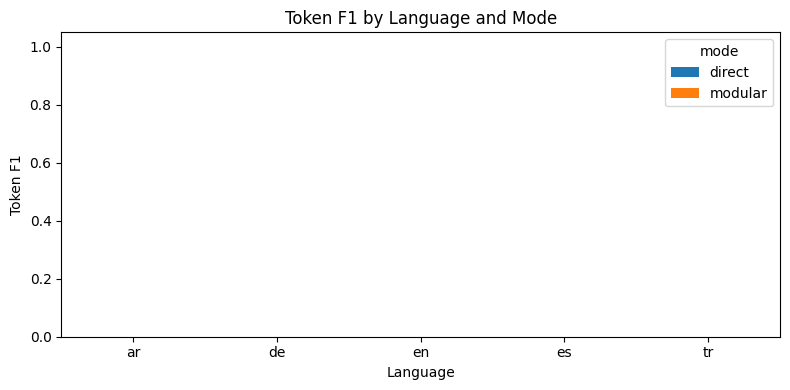

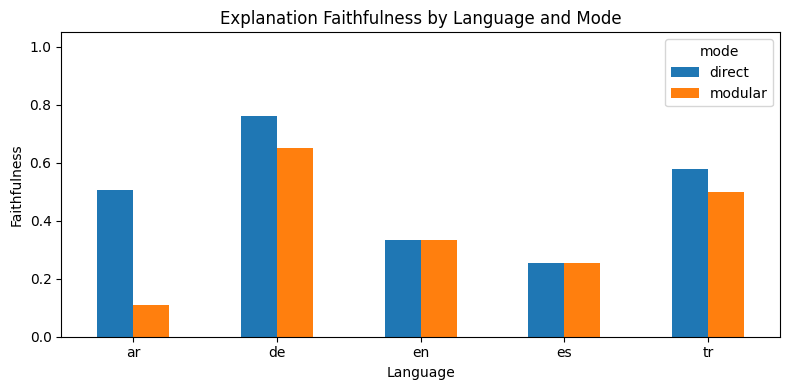

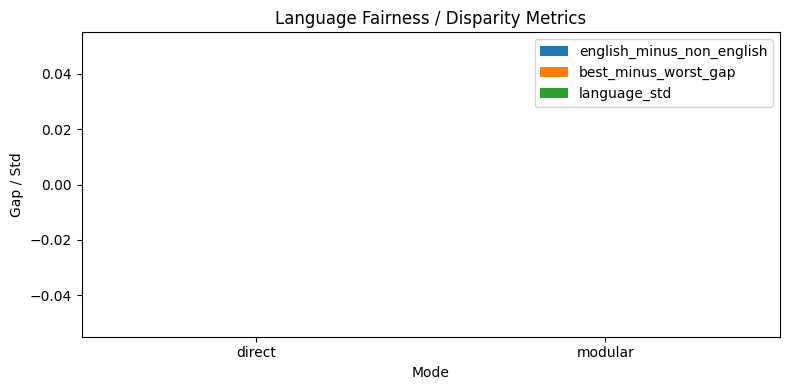

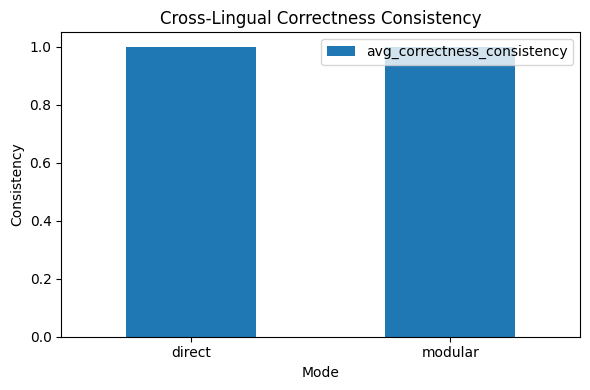

In [52]:
pivot_f1 = summary_by_language.pivot(index="lang", columns="mode", values="token_f1")
pivot_f1.plot(kind="bar", figsize=(8, 4))
plt.title("Token F1 by Language and Mode")
plt.xlabel("Language")
plt.ylabel("Token F1")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

pivot_faith = summary_by_language.pivot(index="lang", columns="mode", values="faithfulness")
pivot_faith.plot(kind="bar", figsize=(8, 4))
plt.title("Explanation Faithfulness by Language and Mode")
plt.xlabel("Language")
plt.ylabel("Faithfulness")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

fairness_df.set_index("mode")[["english_minus_non_english", "best_minus_worst_gap", "language_std"]].plot(kind="bar", figsize=(8, 4))
plt.title("Language Fairness / Disparity Metrics")
plt.xlabel("Mode")
plt.ylabel("Gap / Std")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

consistency_summary.set_index("mode")[["avg_correctness_consistency"]].plot(kind="bar", figsize=(6, 4))
plt.title("Cross-Lingual Correctness Consistency")
plt.xlabel("Mode")
plt.ylabel("Consistency")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 22. Save Outputs

Save the main results as CSV files.


In [53]:
os.makedirs("outputs", exist_ok=True)

xquad_df.to_csv("outputs/xquad_subset.csv", index=False)
direct_scored.to_csv("outputs/direct_scored.csv", index=False)
modular_scored.to_csv("outputs/modular_scored.csv", index=False)
all_results.to_csv("outputs/all_results.csv", index=False)
summary_by_language.to_csv("outputs/summary_by_language.csv", index=False)
summary_by_mode.to_csv("outputs/summary_by_mode.csv", index=False)
fairness_df.to_csv("outputs/language_fairness_metrics.csv", index=False)
consistency_df.to_csv("outputs/cross_lingual_consistency.csv", index=False)

print("Saved files to ./outputs")


Saved files to ./outputs


# 23. Generate Final Report

The final report should summarize:

- model and dataset,
- direct vs modular performance,
- per-language results,
- interpretability findings,
- language-bias / fairness findings,
- limitations,
- possible extensions.


In [54]:
report = f"""
# M³TrustEval-XQuAD Final Report

## 1. Model and Dataset

- Model: `{MODEL_ID}`
- Dataset: `{DATASET_ID}`
- Languages: {list(LANG_CONFIGS.keys())}
- Examples per language: {N_EXAMPLES_PER_LANGUAGE}

## 2. Direct vs Modular Summary

{summary_by_mode.to_markdown(index=False)}

## 3. Per-Language Summary

{summary_by_language.to_markdown(index=False)}

## 4. Language Fairness Metrics

{fairness_df.to_markdown(index=False)}

## 5. Cross-Lingual Consistency

{consistency_summary.to_markdown(index=False)}

## 6. Discussion Questions

1. Did the modular pipeline improve answer quality?
2. Did the modular pipeline improve explanation faithfulness?
3. Which language had the weakest performance?
4. Was English better than the non-English average?
5. Is this performance gap ethically important?
6. What are the limitations of using the same model as generator and verifier?
7. What would improve this evaluation framework?

## 7. Limitations

- The number of examples may be small.
- The model is small and may not follow JSON instructions reliably.
- The verifier uses the same model as the generator.
- Faithfulness metrics are approximate.
- XQuAD evaluates extractive QA and does not directly measure all forms of social bias.
- Language fairness is only one type of bias/ethics analysis.

## 8. Possible Extensions

- Use more XQuAD examples.
- Add all XQuAD languages.
- Compare multiple open-source models.
- Use a stronger verifier model.
- Add a human evaluation of explanations.
- Add a separate social-bias dataset such as BBQ or MBBQ.
"""

with open("outputs/final_report.md", "w", encoding="utf-8") as f:
    f.write(report)

print(report)



# M³TrustEval-XQuAD Final Report

## 1. Model and Dataset

- Model: `Qwen/Qwen2.5-0.5B-Instruct`
- Dataset: `google/xquad`
- Languages: ['en', 'ar', 'de', 'es', 'tr']
- Examples per language: 3

## 2. Direct vs Modular Summary

| mode    |   exact_match |   token_f1 |   fuzzy_match |   faithfulness |   evidence_rate |
|:--------|--------------:|-----------:|--------------:|---------------:|----------------:|
| direct  |             0 |          0 |             0 |       0.486401 |             0.2 |
| modular |             0 |          0 |             0 |       0.369136 |             0.2 |

## 3. Per-Language Summary

| mode    | lang   |   exact_match |   token_f1 |   fuzzy_match |   faithfulness |   evidence_rate |
|:--------|:-------|--------------:|-----------:|--------------:|---------------:|----------------:|
| direct  | ar     |             0 |          0 |             0 |       0.505323 |        0        |
| direct  | de     |             0 |          0 |             0 |      

# 24. Final Written Analysis

Write your final analysis below.

Your answer should include:

1. A short description of the project.
2. A short explanation of HELM and why holistic evaluation matters.
3. A comparison of direct vs modular results.
4. A discussion of explanation faithfulness.
5. A discussion of multilingual performance.
6. A discussion of language bias and ethical implications.
7. At least three limitations.
8. At least three possible extensions.


In [55]:
# Write your final analysis here as a Markdown string or in a Markdown cell.


# 25. Suggested Grading Rubric

| Component | Points |
|---|---:|
| Correct dataset loading and preprocessing | 10 |
| Correct HuggingFace model loading | 10 |
| Direct baseline implementation | 10 |
| Modular pipeline implementation | 20 |
| Evaluation metrics | 15 |
| Interpretability / faithfulness analysis | 10 |
| Multilingual fairness and bias/ethics analysis | 15 |
| Plots and saved outputs | 5 |
| Final written discussion | 5 |

Total: 100
